This notebook investigates whether the GDP per capita of countries have any association with ICE removals over time. We have limitations on the data accessible to us thus, we will be making an assumption that a persons departure country (contained in the ice dataset) is their country of origin.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
gdp = pd.read_csv('API_NY.GDP.PCAP.CD_DS2_en_csv_v2_245.csv', skiprows=4)

print(gdp.head())

                  Country Name Country Code                Indicator Name  \
0                        Aruba          ABW  GDP per capita (current US$)   
1  Africa Eastern and Southern          AFE  GDP per capita (current US$)   
2                  Afghanistan          AFG  GDP per capita (current US$)   
3   Africa Western and Central          AFW  GDP per capita (current US$)   
4                       Angola          AGO  GDP per capita (current US$)   

   Indicator Code        1960        1961        1962        1963        1964  \
0  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
1  NY.GDP.PCAP.CD  186.089204  186.909053  197.367547  225.400079  208.962717   
2  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   
3  NY.GDP.PCAP.CD  121.936832  127.451040  133.823783  139.004980  148.545883   
4  NY.GDP.PCAP.CD         NaN         NaN         NaN         NaN         NaN   

         1965  ...          2017          2018    

In [3]:
#ensures we format data by country
gdp_long = gdp.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(y) for y in range(2010, 2024)],
    var_name='year',
    value_name='gdp_per_capita'
)

gdp_long['year'] = gdp_long['year'].astype(int)
gdp_long = gdp_long.dropna(subset=['gdp_per_capita'])
gdp_long.columns = ['country_name', 'country_code', 'year', 'gdp_per_capita']

print(gdp_long.head())

                  country_name country_code  year  gdp_per_capita
0                        Aruba          ABW  2010    24093.140151
1  Africa Eastern and Southern          AFE  2010     1628.905248
2                  Afghanistan          AFG  2010      560.621505
3   Africa Western and Central          AFW  2010     1662.633658
4                       Angola          AGO  2010     4101.637156


In [4]:
removals = pd.read_csv('removals_10yr.csv', usecols=['Departure Country', 'Departure Date'])

removals['year'] = pd.to_datetime(removals['Departure Date'], errors='coerce').dt.year

removals_by_country = removals.groupby(['Departure Country', 'year']).size().reset_index(name='removal_count')

print(removals_by_country.head())

  Departure Country  year  removal_count
0       AFGHANISTAN  2011              5
1       AFGHANISTAN  2012             18
2       AFGHANISTAN  2013             10
3       AFGHANISTAN  2014             20
4       AFGHANISTAN  2015              4


In [5]:
#join both the gdp and removals dataset
removals_by_country['country_name'] = removals_by_country['Departure Country'].str.title()

merged_gdp = pd.merge(
    removals_by_country,
    gdp_long,
    on=['country_name', 'year'],
    how='inner'
)

print(merged_gdp.shape)
print(merged_gdp.head())

(1611, 6)
  Departure Country  year  removal_count country_name country_code  \
0       AFGHANISTAN  2011              5  Afghanistan          AFG   
1       AFGHANISTAN  2012             18  Afghanistan          AFG   
2       AFGHANISTAN  2013             10  Afghanistan          AFG   
3       AFGHANISTAN  2014             20  Afghanistan          AFG   
4       AFGHANISTAN  2015              4  Afghanistan          AFG   

   gdp_per_capita  
0      606.694676  
1      651.417134  
2      637.087099  
3      625.054942  
4      565.569730  


In [6]:
top10 = merged_gdp.groupby('country_name').agg(
    total_removals=('removal_count', 'sum'),
    avg_gdp=('gdp_per_capita', 'mean')
).nlargest(10, 'total_removals').reset_index()

print(top10)

         country_name  total_removals       avg_gdp
0              Mexico         1534414  10217.719766
1           Guatemala          383620   4011.157443
2            Honduras          268805   2314.726675
3         El Salvador          178090   3902.914855
4  Dominican Republic           21070   7052.343931
5             Ecuador           16985   5951.266427
6              Brazil           16128  10171.131672
7           Nicaragua           12529   1974.326975
8            Colombia           11751   6865.055943
9               Haiti           11574   1426.948499


These are the top 10 countries with the most removals and their corresponding average gdp per capita. Mexico is leading with upwards of a million removals.

In [7]:
def plot_country(country_name, exclude_years=[]):
    subset = merged_gdp[merged_gdp['country_name'] == country_name].sort_values('year')
    subset = subset[~subset['year'].isin(exclude_years)]
    
    corr = subset['removal_count'].corr(subset['gdp_per_capita'])
    print(f"{country_name} — Correlation between removals and GDP: {corr:.4f}")
    
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    
    ax1.plot(subset['year'], subset['removal_count'], label='Removals')
    ax2.plot(subset['year'], subset['gdp_per_capita'], color='red', label='GDP per Capita')
    
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Removals')
    ax2.set_ylabel('GDP per Capita (USD)', color='red')
    ax1.tick_params(axis='x', rotation=45)
    
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    
    title = f'{country_name} — Removals vs GDP per Capita Over Time'
    plt.title(title)
    plt.show()

Mexico — Correlation between removals and GDP: 0.3518


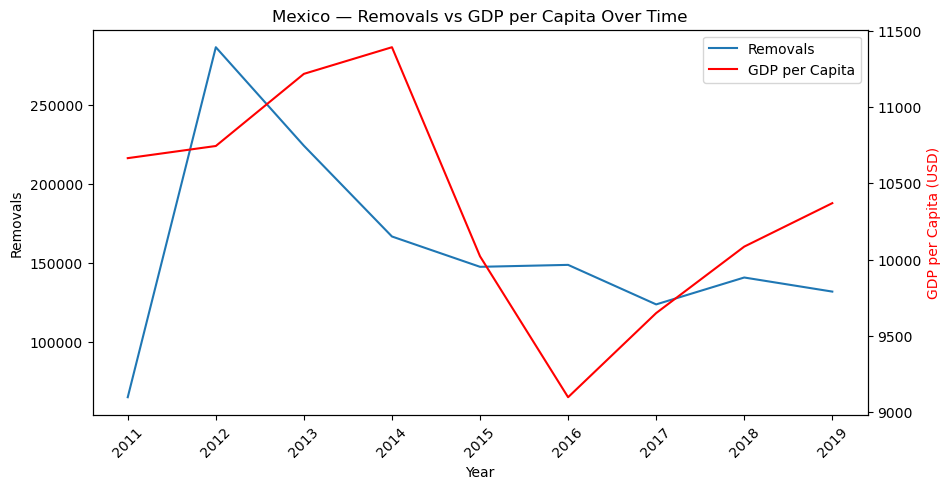

Guatemala — Correlation between removals and GDP: 0.4878


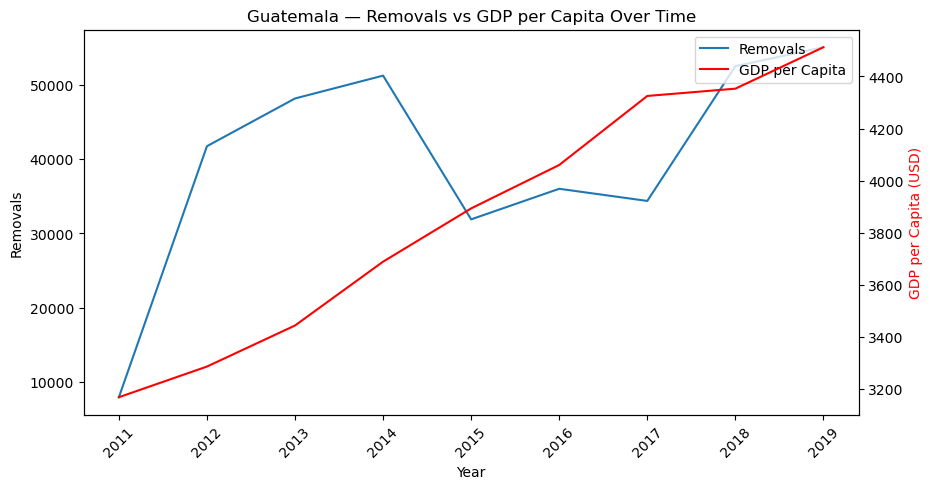

Honduras — Correlation between removals and GDP: 0.2436


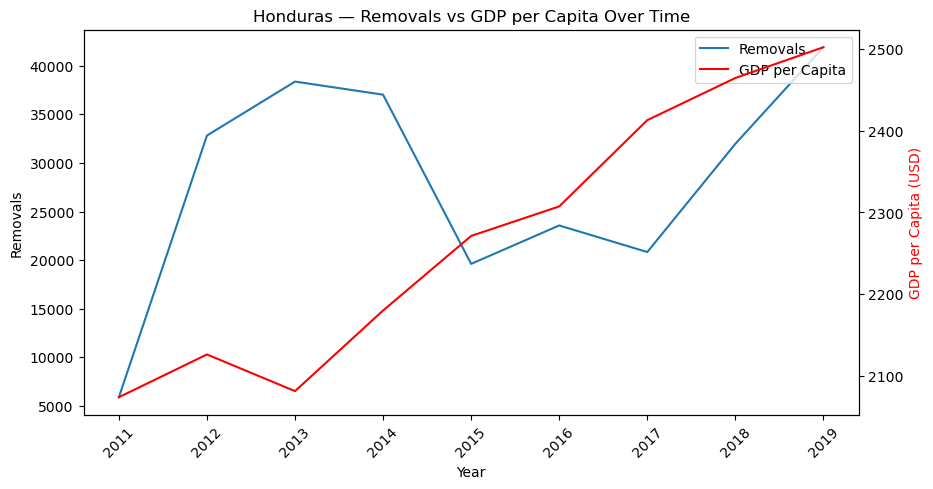

El Salvador — Correlation between removals and GDP: 0.2247


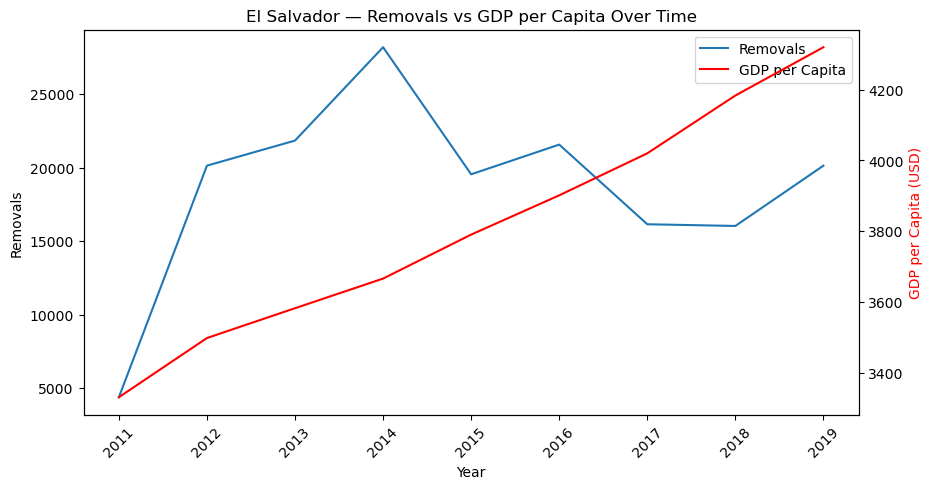

Dominican Republic — Correlation between removals and GDP: 0.0231


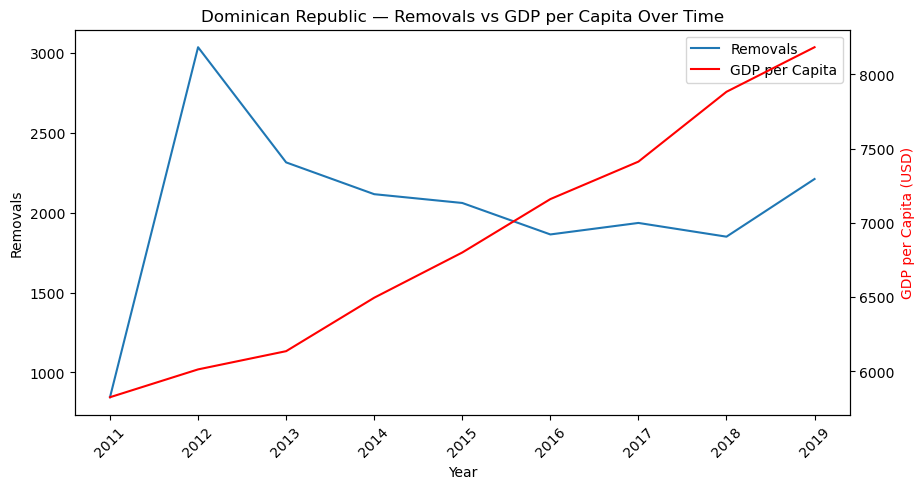

Ecuador — Correlation between removals and GDP: 0.4776


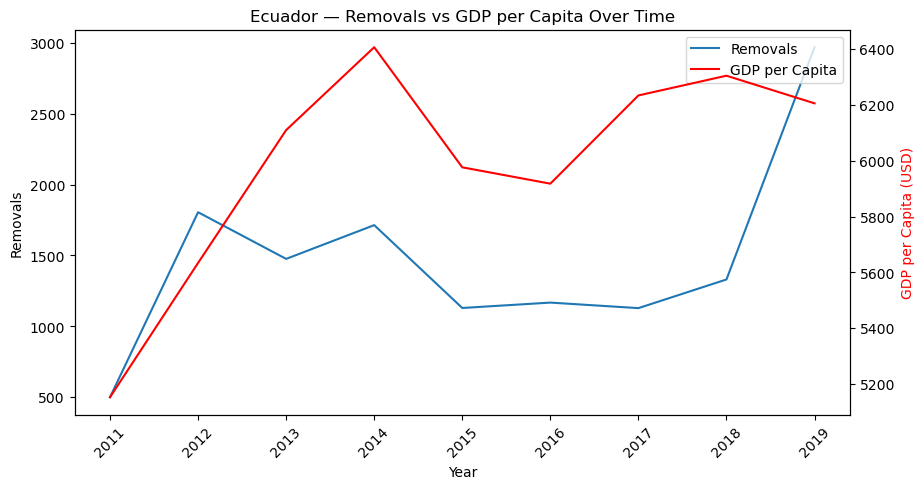

Brazil — Correlation between removals and GDP: -0.2068


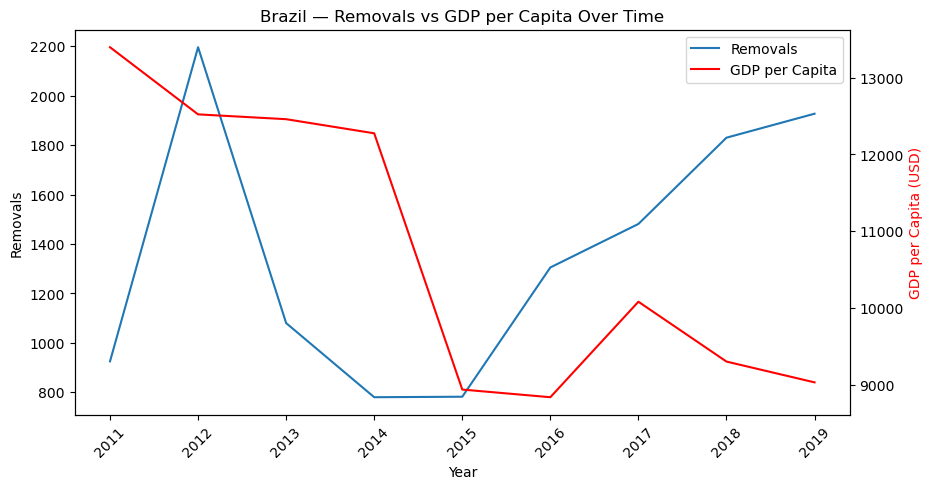

Haiti — Correlation between removals and GDP: -0.0932


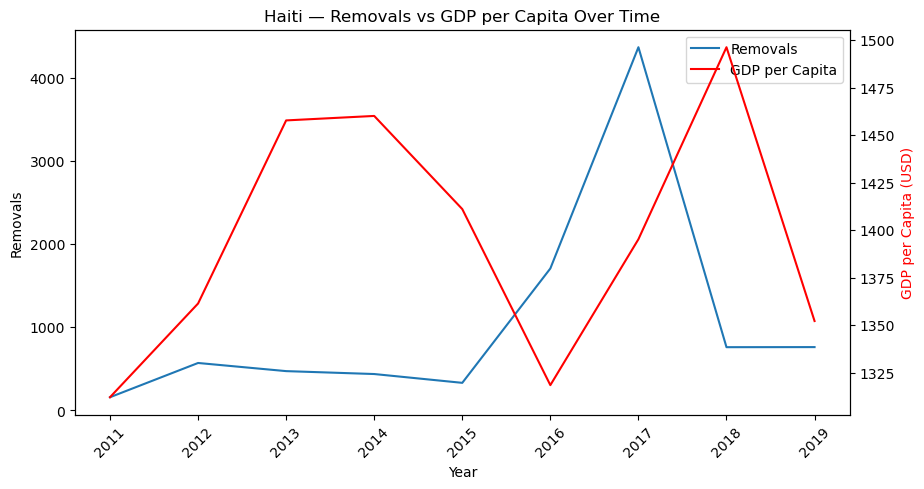

Colombia — Correlation between removals and GDP: 0.1522


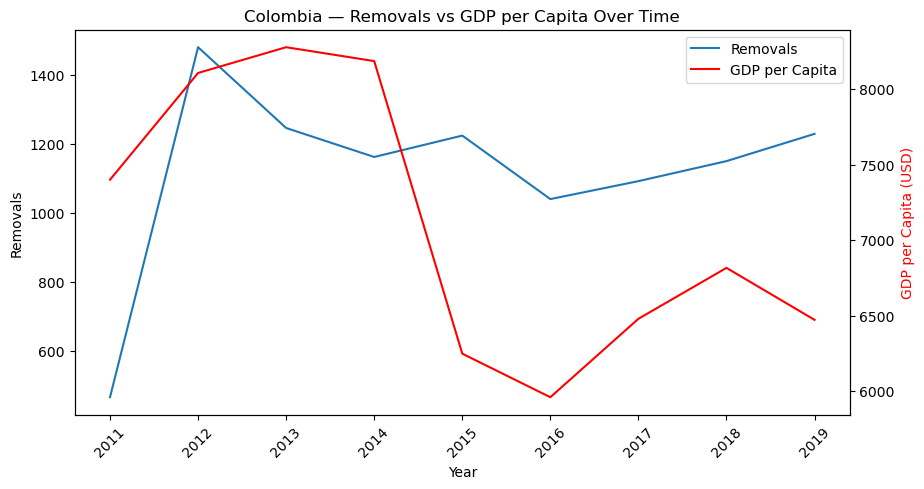

Canada — Correlation between removals and GDP: -0.1264


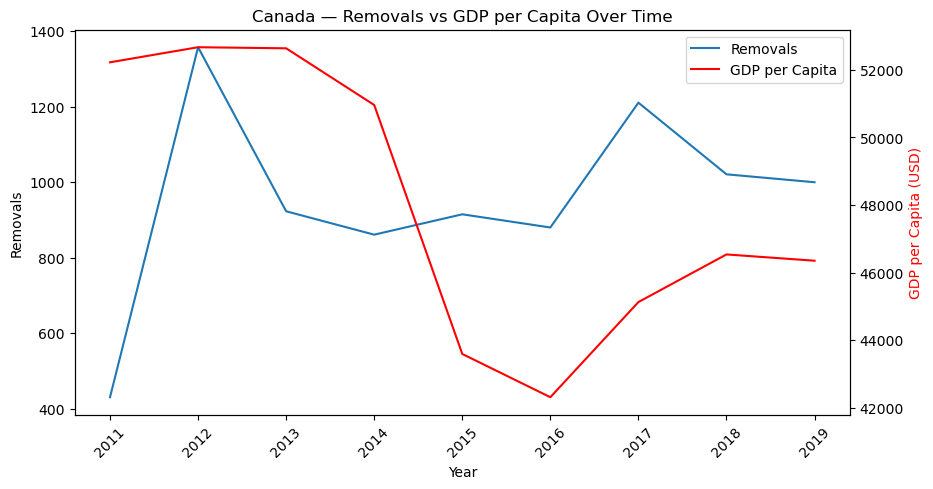

In [8]:
plot_country('Mexico', exclude_years=[2020, 2021])
plot_country('Guatemala', exclude_years=[2020, 2021])
plot_country('Honduras', exclude_years=[2020, 2021])
plot_country('El Salvador', exclude_years=[2020, 2021])
plot_country('Dominican Republic', exclude_years=[2020, 2021])
plot_country('Ecuador', exclude_years=[2020, 2021])
plot_country('Brazil', exclude_years=[2020, 2021])
plot_country('Haiti', exclude_years=[2020, 2021])
plot_country('Colombia', exclude_years=[2020, 2021])
plot_country('Canada', exclude_years=[2020, 2021])

Across the top 10 countries with the highest removals, there are no consistently strong correlations between GDP and removal counts. It also worth noting that a majority of these countries are Latin American, with Mexico leading by a large margin. This could suggest that removal volume may be driven more by georaphic proximity to the US than by economic reasons as there are no consitent correlations.